In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')


In [15]:
# Đọc dữ liệu từ file CSV 
df = pd.read_csv("food_prediction_2014_from_2012.csv", sep=',')
df.head()

,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,target_food_2014
0,10010000400815,1,5,1,33,NaN,1,2.0,500.0,0.0,...,2.0,2.0,500,0,0.0,5717,343000,207000.0,136000.0,27163.0
1,10010002802514,1,5,2,60,NaN,1,1.0,120.0,0.0,...,1.0,2.0,500,0,125.0,2709,162525,150400.0,12000.0,14542.0
2,10020006701613,1,5,1,51,NaN,1,1.0,550.0,0.0,...,2.0,2.0,700,0,0.0,3922,235290,67100.0,7200.0,9611.0
3,10040013903013,1,1,1,52,NaN,1,NaN,NaN,NaN,...,2.0,2.0,200,50,0.0,15500,186000,147000.0,39000.0,2740.0
4,10050016703013,1,2,1,63,NaN,1,2.0,0.0,0.0,...,1.0,2.0,300,1050,0.0,21654,519700,210500.0,158000.0,7351.5


In [16]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   h_code                1635 non-null   int64  
 1   tinh                  1635 non-null   int64  
 2   household_size        1635 non-null   int64  
 3   head_gender           1635 non-null   int64  
 4   head_age              1635 non-null   int64  
 5   area_type1            3 non-null      float64
 6   area_type2            1635 non-null   int64  
 7   outpatient_visits     1229 non-null   float64
 8   outpatient_cost       1124 non-null   float64
 9   inpatient_visits      1229 non-null   float64
 10  inpatient_cost        416 non-null    float64
 11  insurance_premium     807 non-null    float64
 12  insurance_outpatient  1464 non-null   float64
 13  insurance_inpatient   1464 non-null   float64
 14  medicine_cost         1635 non-null   int64  
 15  equipment_cost       

In [17]:
# Kiểm tra giá trị thiếu
df.isnull().sum()

h_code                     0
tinh                       0
household_size             0
head_gender                0
head_age                   0
area_type1              1632
area_type2                 0
outpatient_visits        406
outpatient_cost          511
inpatient_visits         406
inpatient_cost          1219
insurance_premium        828
insurance_outpatient     171
insurance_inpatient      171
medicine_cost              0
equipment_cost             0
health_subsidy             0
thubq                      0
thunhap                    0
salary                     0
other_income               0
target_food_2014           0
dtype: int64

In [18]:
# Fill missing values for continuous variables with mean (only keep columns that exist)
numerical_cols = ['outpatient_visits', 'outpatient_cost', 'inpatient_visits', 'inpatient_cost',
                  'insurance_premium', 'area_type1']
numerical_cols = [col for col in numerical_cols if col in df.columns]

for col in numerical_cols:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)

# Fill missing values for categorical-like variables with mode (only if they exist)
categorical_cols = ['insurance_outpatient', 'insurance_inpatient']
categorical_cols = [col for col in categorical_cols if col in df.columns]

for col in categorical_cols:
    modes = df[col].mode()
    if not modes.empty:
        df[col].fillna(modes.iloc[0], inplace=True)
    else:
        df[col].fillna(0, inplace=True)

# Quick check
print("Missing values after imputation:")
print(df[numerical_cols + categorical_cols].isnull().sum())

Missing values after imputation:
outpatient_visits       0
outpatient_cost         0
inpatient_visits        0
inpatient_cost          0
insurance_premium       0
area_type1              0
insurance_outpatient    0
insurance_inpatient     0
dtype: int64


In [19]:
summary = df.describe(include='all')
summary

,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,target_food_2014
count,1.635000e+03,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.00000,1635.000000,...,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03,1635.000000,1.635000e+03,1635.000000
mean,4.776141e+14,47.285015,3.883180,1.220183,49.781651,64.666667,1.012232,2.662327,1005.86121,0.269325,...,1.695413,1.907645,589.521713,40.614067,941.909480,2072.075841,9.129448e+04,39119.885627,1.064759e+04,4484.486361
std,2.775770e+14,27.488299,1.491036,0.414497,14.079010,0.828156,0.125547,3.634870,4090.73000,0.601840,...,0.460373,0.289615,1553.856805,127.679769,6898.575419,2480.664194,9.572851e+04,56713.723343,5.138432e+04,3761.977140
min,1.001000e+13,1.000000,1.000000,1.000000,20.000000,51.000000,1.000000,0.000000,0.00000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,212.000000,3.400000e+03,0.000000,-1.140000e+03,360.000000
25%,2.523708e+14,25.000000,3.000000,1.000000,40.000000,64.666667,1.000000,1.000000,100.00000,0.000000,...,1.000000,2.000000,100.000000,0.000000,0.000000,942.500000,3.949450e+04,0.000000,5.025000e+02,2311.500000
50%,4.445519e+14,44.000000,4.000000,1.000000,48.000000,64.666667,1.000000,2.000000,550.00000,0.000000,...,2.000000,2.000000,250.000000,0.000000,0.000000,1586.000000,7.108500e+04,19500.000000,2.050000e+03,3558.000000
75%,7.271026e+14,72.000000,5.000000,1.000000,58.000000,64.666667,1.000000,2.662327,1005.86121,0.269325,...,2.000000,2.000000,500.000000,30.000000,295.000000,2544.000000,1.141320e+05,56487.500000,8.655000e+03,5460.000000
max,9.697332e+14,96.000000,11.000000,2.000000,95.000000,92.000000,3.000000,60.000000,125000.00000,12.000000,...,2.000000,2.000000,27000.000000,2000.000000,200000.000000,64972.000000,2.339000e+06,458750.000000,1.905000e+06,55787.000000


In [20]:
# Mã hóa biến định tính bằng LabelEncoder
le = LabelEncoder()
for col in ['tinh', 'head_gender', 'area_type2', 'insurance_outpatient', 'insurance_inpatient']:
    df[col] = le.fit_transform(df[col])

# Kiểm tra phân phối biến mục tiêu
print("\nPhân phối biến mục tiêu target_food_2014:")
print(df['target_food_2014'].describe())


Phân phối biến mục tiêu target_food_2014:
count     1635.000000
mean      4484.486361
std       3761.977140
min        360.000000
25%       2311.500000
50%       3558.000000
75%       5460.000000
max      55787.000000
Name: target_food_2014, dtype: float64



Tầm quan trọng của các đặc trưng:
                Variable  Importance
17               thunhap    0.351759
18                salary    0.103883
16                 thubq    0.076232
19          other_income    0.073821
0                   tinh    0.066318
3               head_age    0.059516
13         medicine_cost    0.049663
10     insurance_premium    0.044868
7        outpatient_cost    0.034270
6      outpatient_visits    0.031010
1         household_size    0.029769
14        equipment_cost    0.022562
9         inpatient_cost    0.017470
15        health_subsidy    0.015968
8       inpatient_visits    0.007486
5             area_type2    0.003775
11  insurance_outpatient    0.003588
2            head_gender    0.003532
4             area_type1    0.002900
12   insurance_inpatient    0.001610


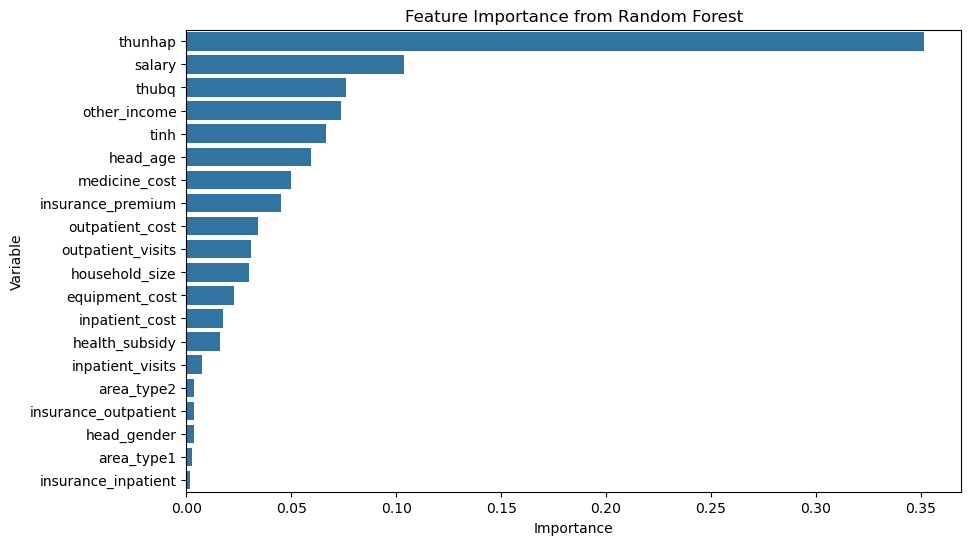


Các biến quan trọng được giữ lại: ['thunhap', 'salary', 'thubq', 'other_income', 'tinh']


,thunhap,salary,thubq,other_income,tinh,target_food_2014
0,343000,207000.0,5717,136000.0,0,27163.0
1,162525,150400.0,2709,12000.0,0,14542.0
2,235290,67100.0,3922,7200.0,0,9611.0
3,186000,147000.0,15500,39000.0,0,2740.0
4,519700,210500.0,21654,158000.0,0,7351.5


In [21]:
# Sử dụng Random Forest để đánh giá tầm quan trọng của các đặc trưng
X = df.drop(['target_food_2014', 'h_code'], axis=1)
y = df['target_food_2014']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Tầm quan trọng của các đặc trưng
feature_importance = pd.DataFrame({'Variable': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng của các đặc trưng:")
print(feature_importance)

# Vẽ biểu đồ tầm quan trọng của các đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feature_importance)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.show()

# Chọn các biến quan trọng (giữ lại các biến có tầm quan trọng > 0.06
important_features = feature_importance[feature_importance['Importance'] > 0.06]['Variable'].tolist()
print("\nCác biến quan trọng được giữ lại:", important_features)

# Tạo DataFrame mới chỉ chứa các biến quan trọng và target_food_2014
df = df[important_features + ['target_food_2014']]
df.head()


In [22]:
#  Tách features (X) và target (y)
continuous_vars = []
discrete_vars = []

for col in df.columns:
    if col != 'target_food_2014':
        if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 15:
            continuous_vars.append(col)
        else:
            discrete_vars.append(col)

print("\nBiến liên tục:", continuous_vars)
print("Biến rời rạc:", discrete_vars)


Biến liên tục: ['thunhap', 'salary', 'thubq', 'other_income', 'tinh']
Biến rời rạc: []


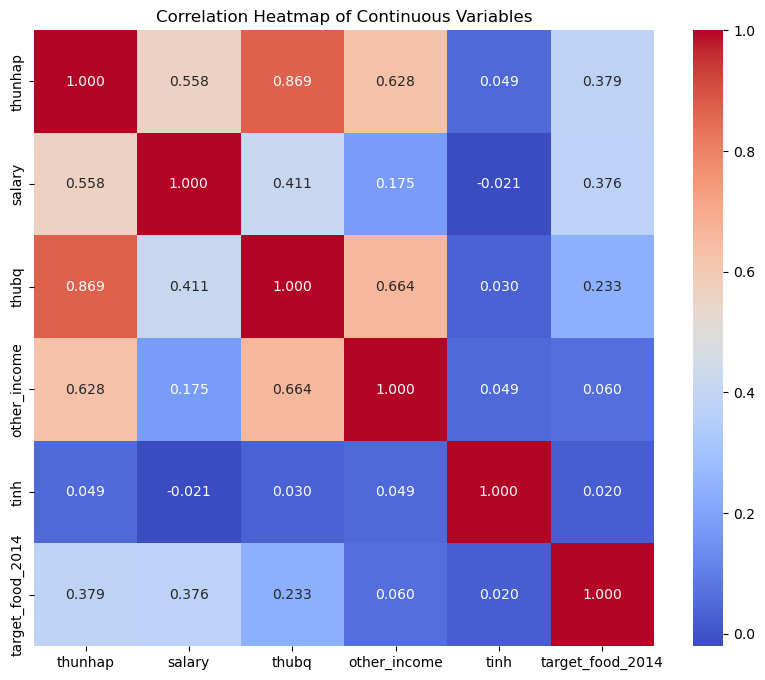

In [23]:
# Phân tích biến liên tục: Heatmap tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(df[continuous_vars + ['target_food_2014']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap of Continuous Variables')
plt.show()

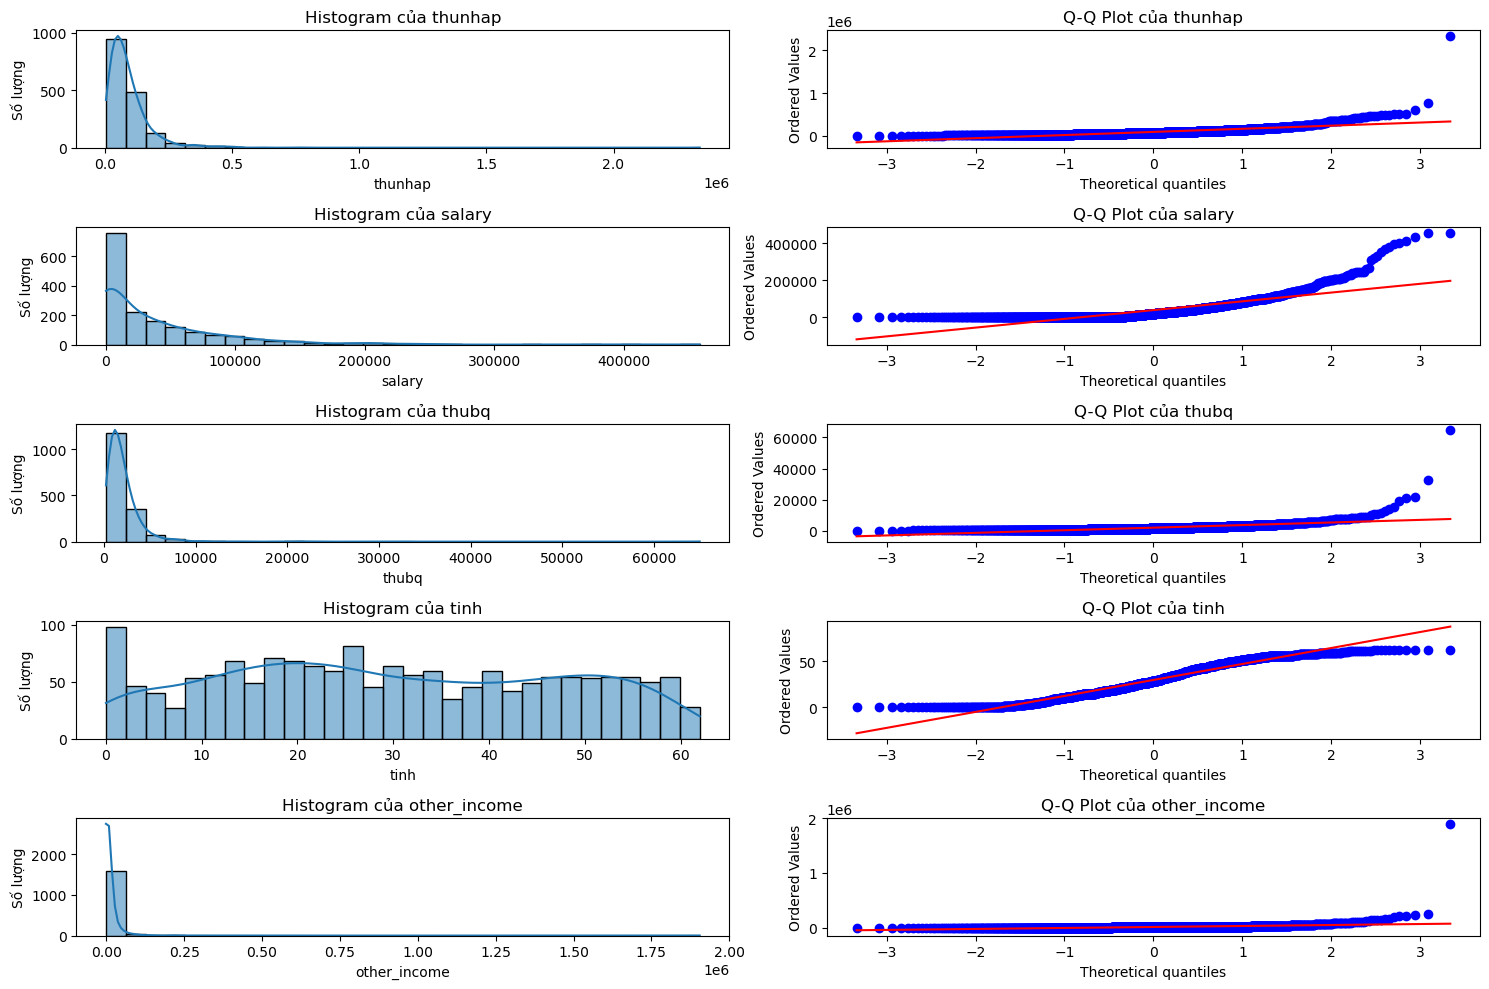


Kiểm định Shapiro-Wilk cho thunhap:
Statistic: 0.5860, p-value: 2.3502e-52
thunhap KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho salary:
Statistic: 0.7004, p-value: 4.2753e-47
salary KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho thubq:
Statistic: 0.4531, p-value: 4.0680e-57
thubq KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho tinh:
Statistic: 0.9585, p-value: 3.4219e-21
tinh KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho other_income:
Statistic: 0.1263, p-value: 1.3023e-65
other_income KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).


In [24]:

from scipy.stats import shapiro, probplot

# Danh sách các biến liên tục
continuous_vars = ['thunhap', 'salary', 'thubq', 'tinh', 'other_income']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(15, 10))

# Kiểm tra phân phối chuẩn cho từng biến
for i, var in enumerate(continuous_vars, 1):
    # 1. Histogram
    plt.subplot(len(continuous_vars), 2, 2*i-1)
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f'Histogram của {var}')
    plt.xlabel(var)
    plt.ylabel('Số lượng')

    # 2. Q-Q Plot
    plt.subplot(len(continuous_vars), 2, 2*i)
    probplot(df[var], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot của {var}')

plt.tight_layout()
plt.show()

# 3. Kiểm định Shapiro-Wilk
for var in continuous_vars:
    stat, p_value = shapiro(df[var])
    print(f'\nKiểm định Shapiro-Wilk cho {var}:')
    print(f'Statistic: {stat:.4f}, p-value: {p_value:.4e}')
    if p_value < 0.05:
        print(f'{var} KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).')
    else:
        print(f'{var} có thể tuân theo phân phối chuẩn (p-value >= 0.05).')


Biến đổi cho biến không chuẩn: thunhap

Sau log transform:
Shapiro-Wilk: Statistics=0.991, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.921, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.996, p-value=0.000


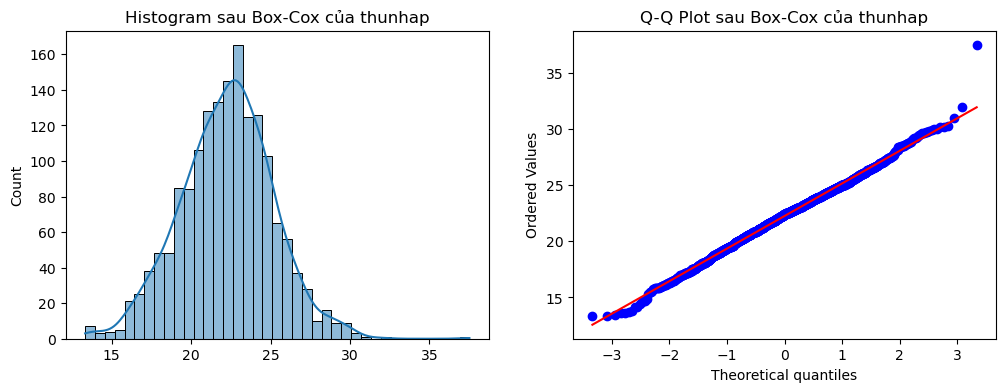


Biến đổi cho biến không chuẩn: salary

Sau log transform:
Shapiro-Wilk: Statistics=0.725, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.893, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.803, p-value=0.000


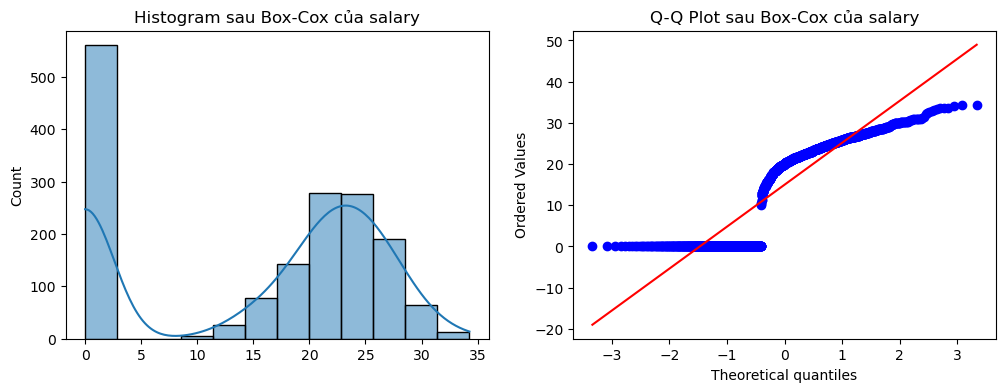


Biến đổi cho biến không chuẩn: thubq

Sau log transform:
Shapiro-Wilk: Statistics=0.994, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.863, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.995, p-value=0.000


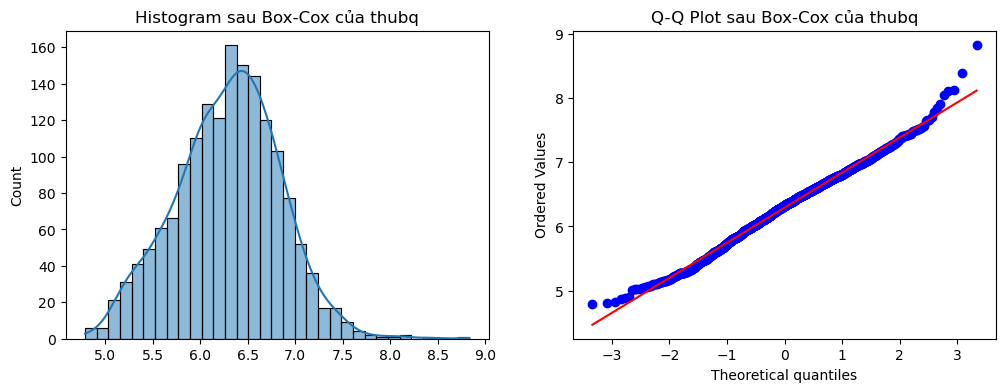


Biến đổi cho biến không chuẩn: tinh

Sau log transform:
Shapiro-Wilk: Statistics=0.832, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.950, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.962, p-value=0.000


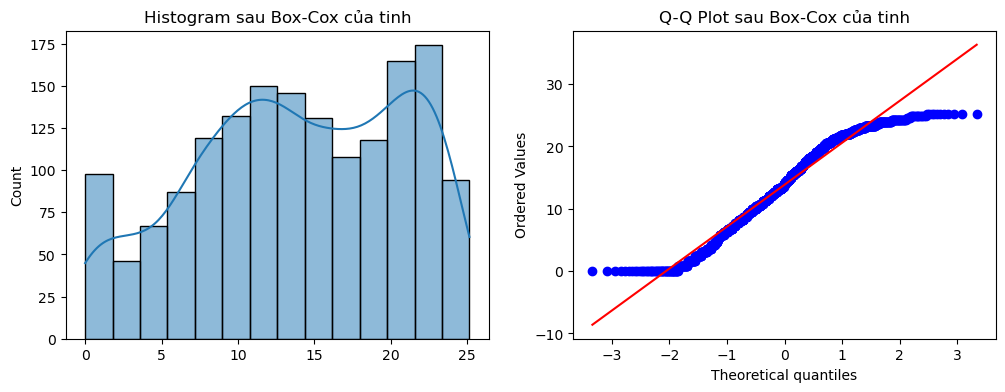


Biến đổi cho biến không chuẩn: other_income

Sau log transform:
Shapiro-Wilk: Statistics=0.909, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.633, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.901, p-value=0.000


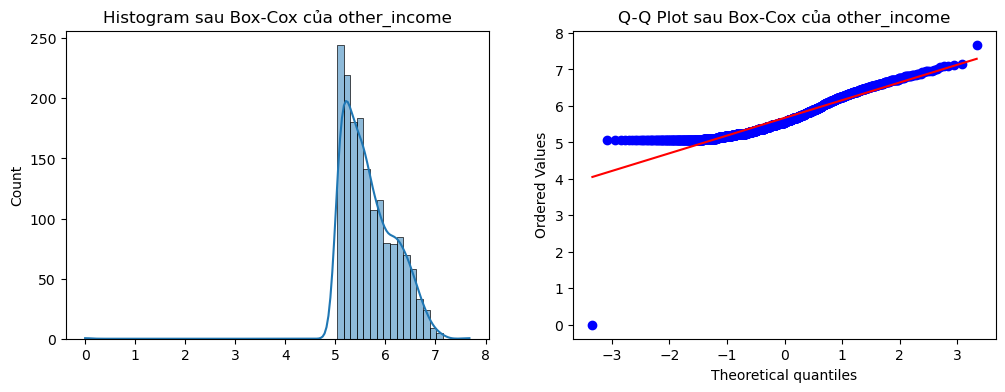

,thunhap,salary,thubq,other_income,tinh,target_food_2014,thunhap_boxcox,salary_boxcox,thubq_boxcox,tinh_boxcox,other_income_boxcox
0,343000,207000.0,5717,136000.0,0,27163.0,28.483720,30.138924,7.235576,0.0,6.962033
1,162525,150400.0,2709,12000.0,0,14542.0,25.464438,28.597693,6.710706,0.0,6.145441
2,235290,67100.0,3922,7200.0,0,9611.0,26.928275,24.977430,6.972833,0.0,5.963983
3,186000,147000.0,15500,39000.0,0,2740.0,25.991154,28.489804,7.910958,0.0,6.557962
4,519700,210500.0,21654,158000.0,0,7351.5,30.276962,30.221611,8.131013,0.0,7.007705


In [25]:
# Hàm biến đổi và kiểm tra lại
from scipy import stats
from scipy.stats import boxcox

def transform_and_check(df, var):
    print(f"\nBiến đổi cho biến không chuẩn: {var}")
    
    # Xử lý giá trị âm/zero 
    if (df[var] <= 0).any():
        shifted = df[var] - df[var].min() + 1  
    else:
        shifted = df[var]
    
    # Thử các biến đổi
    transformations = {
        'log': np.log(shifted),  # Log transform (cho skew positive)
        'sqrt': np.sqrt(shifted)  # Square root (cho skew moderate)
    }
    
    # Thử Box-Cox (cần giá trị dương và không phải hằng số)
    try:
        boxcox_transformed = boxcox(shifted)[0]
        transformations['boxcox'] = boxcox_transformed
    except Exception as e:
        # Nếu Box-Cox thất bại , in thông báo và dùng shifted làm fallback
        print(f"Box-Cox failed for {var}: {e}")
        transformations['boxcox'] = shifted
    
    # Kiểm tra normality sau từng biến đổi
    for trans_name, trans_data in transformations.items():
        print(f"\nSau {trans_name} transform:")
        try:
            stat, p = stats.shapiro(trans_data)
            print(f'Shapiro-Wilk: Statistics={stat:.3f}, p-value={p:.3f}')
            if p > 0.05:
                print("Bây giờ gần chuẩn hơn!")
        except Exception as e:
            print(f"Shapiro-Wilk test failed for {var} after {trans_name}: {e}")
            continue
        
        # Visualize sau transform 
        if trans_name == 'boxcox':
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            sns.histplot(trans_data, kde=True)
            plt.title(f'Histogram sau Box-Cox của {var}')
            
            plt.subplot(1, 2, 2)
            stats.probplot(trans_data, dist="norm", plot=plt)
            plt.title(f'Q-Q Plot sau Box-Cox của {var}')
            plt.show()
    
    # Lưu biến đổi tốt nhất vào df mới
    df[var + '_boxcox'] = transformations['boxcox']
    return df

# Áp dụng cho các biến không chuẩn 
non_normal_vars = ['thunhap','salary', 'thubq', 'tinh', 'other_income'] 
for var in non_normal_vars:
    df = transform_and_check(df, var)

# Xem data sau biến đổi
df.head()

Linear Regression - MSE: 23331613.55, R2: 0.09
Random Forest - MSE: 23680459.61, R2: 0.07
Mean chi tiêu thức ăn thực tế (2014): 4484.49
Mean chi tiêu thức ăn dự đoán (dựa trên 2012): 4376.65


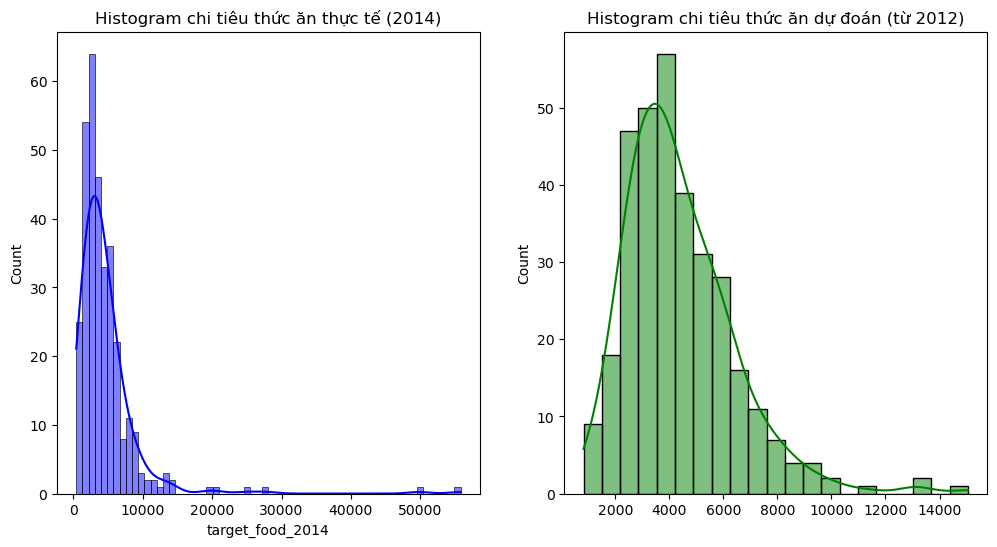


Kết luận dựa trên dữ liệu (dự đoán cho cả nước):
Nhu cầu chi tiêu thức ăn dự kiến giảm hoặc ổn định, nên tập trung vào dự trữ đồ ăn để tránh lãng phí.
Lý do: Dựa trên mô hình dự đoán từ dữ liệu 2012, mean chi tiêu thức ăn ước tính cho 2014 là 4376.65, so với thực tế 4484.49.


In [26]:

from scipy.stats import boxcox
boxcox_vars = ['salary', 'other_income', 'tinh', 'thunhap', 'thubq']
for v in boxcox_vars:
    col_name = v + '_boxcox'
    if col_name not in df.columns:
        shifted = df[v].copy()
        if (shifted <= 0).any():
            shifted = shifted - shifted.min() + 1
        df[col_name] = boxcox(shifted)[0]

# DANH SÁCH FEATURES 
features = [
    'tinh_boxcox', 'thubq_boxcox', 'thunhap_boxcox', 'salary_boxcox', 'other_income_boxcox'
]

target = 'target_food_2014'

# Kiểm tra các feature thực sự tồn tại trong df và loại bỏ những feature mất do các bước trước đó
available_features = [col for col in features if col in df.columns]
missing_features = [col for col in features if col not in df.columns]
if missing_features:
    print("Warning: các feature sau không tồn tại trong df và sẽ bị loại bỏ:", missing_features)

# Đảm bảo target tồn tại
if target not in df.columns:
    raise KeyError(f"Target '{target}' không tồn tại trong DataFrame hiện tại.")

# Nếu không còn feature nào sau khi lọc thì dừng lại
if len(available_features) == 0:
    raise ValueError("Không có feature nào hợp lệ để huấn luyện. Kiểm tra lại các bước tiền xử lý trước đó.")

# Chia dữ liệu thành train và test (80/20)
X = df[available_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train mô hình Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Dự đoán trên test set
y_pred_lr = lr_model.predict(X_test)

# Đánh giá mô hình
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MSE: {mse_lr:.2f}, R2: {r2_lr:.2f}")

# Train mô hình Random Forest Regressor 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán trên test set
y_pred_rf = rf_model.predict(X_test)

# Đánh giá mô hình
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MSE: {mse_rf:.2f}, R2: {r2_rf:.2f}")

# Sử dụng Random Forest 
y_pred = y_pred_rf 

# Tính mean của target thực tế và dự đoán
mean_actual = y.mean()
mean_predicted = pd.Series(y_pred).mean()  

print(f"Mean chi tiêu thức ăn thực tế (2014): {mean_actual:.2f}")
print(f"Mean chi tiêu thức ăn dự đoán (dựa trên 2012): {mean_predicted:.2f}")

# Vẽ histogram để so sánh phân bố
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(y_test, kde=True, color='blue')
plt.title('Histogram chi tiêu thức ăn thực tế (2014)')

plt.subplot(1, 2, 2)
sns.histplot(y_pred, kde=True, color='green')
plt.title('Histogram chi tiêu thức ăn dự đoán (từ 2012)')
plt.show()

# Decision dựa trên mean: Nếu mean dự đoán > mean thực tế, có thể nhu cầu tăng -> cần sản xuất thêm
# Ngược lại, nhu cầu giảm -> có thể dự trữ
if mean_predicted > mean_actual:
    decision = "Nhu cầu chi tiêu thức ăn dự kiến tăng so với thực tế, nên khuyến nghị sản xuất thêm để đáp ứng nhu cầu cho cả nước."
else:
    decision = "Nhu cầu chi tiêu thức ăn dự kiến giảm hoặc ổn định, nên tập trung vào dự trữ đồ ăn để tránh lãng phí."

print("\nKết luận dựa trên dữ liệu (dự đoán cho cả nước):")
print(decision)
print("Lý do: Dựa trên mô hình dự đoán từ dữ liệu 2012, mean chi tiêu thức ăn ước tính cho 2014 là {:.2f}, so với thực tế {:.2f}.".format(mean_predicted, mean_actual))